In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [9]:
df = pd.read_csv("Titanic-Dataset.csv")
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [10]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(891, 12)


In [11]:
print("\nDataset information")
df.info()


Dataset information
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [13]:
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
print("missing value:")
print(df.isnull().sum())

missing value:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [24]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

Cabin          77.104377
PassengerId     0.000000
Pclass          0.000000
Survived        0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Age             0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Embarked        0.000000
dtype: float64


In [25]:
df = df.drop(columns=["Cabin"])

In [26]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [30]:
label_encoder = LabelEncoder()
df["Sex"] = label_encoder.fit_transform(df["Sex"])
print(df["Sex"].value_counts())

Sex
1    577
0    314
Name: count, dtype: int64


In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

embarked_encoded = encoder.fit_transform(df[["Embarked"]])
embarked_encoded_df = pd.DataFrame(
    embarked_encoded,
    columns=encoder.get_feature_names_out(["Embarked"]),
    index=df.index
)


In [46]:
df = pd.concat([df, embarked_encoded_df], axis=1)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S,Embarked_C,Embarked_Q,Embarked_S,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


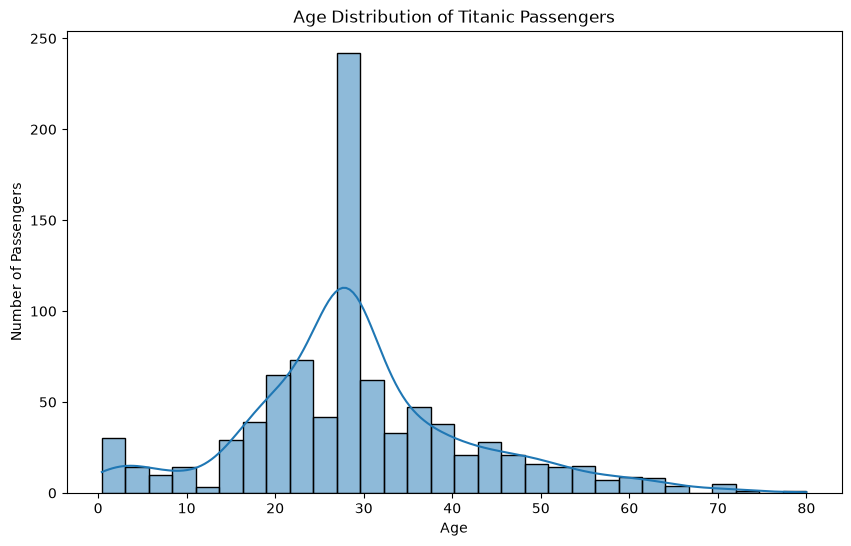

In [59]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.savefig("age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [50]:
print("Cleaned Dataset Shape:")
print(df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

print("\nCleaned Dataset:")
print(df.head())

Cleaned Dataset Shape:
(891, 19)

Remaining Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
Embarked_C     0
Embarked_Q     0
Embarked_S     0
dtype: int64

Cleaned Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily Ma

In [51]:
df.to_csv("titanic_cleaned.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


In [57]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived"])
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Training data:", X_test.shape)

Training data: (712, 18)
Training data: (179, 18)


## Conclusion

In this Week 1 project, the Titanic dataset was explored and preprocessed using Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

Missing values were handled using median and mode imputation. The Sex column was encoded using LabelEncoder, while the Embarked column was encoded using OneHotEncoder. The age distribution was visualized using Seaborn, and the cleaned dataset was exported as titanic_cleaned.csv.

A train-test split was also performed to prepare the dataset for future machine learning tasks.
    